<a href="https://colab.research.google.com/github/cris73tian/TPF-IA-PlantVillage/blob/main/TPF_IA_Plant_Village.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalación y configuración del dataset de Kaggle

In [3]:
import os
import pathlib
import random
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Configuración inicial para garantizar reproducibilidad en los experimentos
np.random.seed(42)
tf.random.set_seed(42)

print("Todas las librerías han sido importadas y configuradas correctamente.")

Todas las librerías han sido importadas y configuradas correctamente.


Se agrupan todas las dependencias necesarias en un solo lugar al inicio del notebook siguiendo las buenas prácticas de desarrollo en ciencia de datos.

Se importan herramientas de manipulación numérica (numpy, pandas), visualización (matplotlib, seaborn), procesamiento de imágenes (cv2), manejo de directorios (os, pathlib, zipfile), partición de datos (sklearn), y el framework de Deep Learning (tensorflow/keras) para construir y entrenar las redes neuronales.

## Carga y descarga del Dataset desde Kaggle

In [4]:
!pip install -q kaggle

# Descarga del dataset Plant Village (Updated) de Tushar Sharma
!kaggle datasets download -d tushar5harma/plant-village-dataset-updated

# Descompresión del archivo ZIP descargado en un directorio local de trabajo
with zipfile.ZipFile('plant-village-dataset-updated.zip', 'r') as zip_ref:
    zip_ref.extractall('plant_village_data')

print("Dataset descargado y descomprimido con éxito en el directorio 'plant_village_data'.")

Dataset URL: https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated
License(s): CC0-1.0
plant-village-dataset-updated.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset descargado y descomprimido con éxito en el directorio 'plant_village_data'.


Este bloque descarga directamente los archivos comprimidos del dataset asignado desde Kaggle usando su API y los extrae en el almacenamiento local de la máquina virtual de Colab para que puedan ser leídos por el código en las siguientes etapas.

## Análisis Exploratorio de Datos (EDA) y Visualización

Número total de imágenes encontradas (aprox): 0
Clases / Especies identificadas: ['Potato' 'Cherry' 'Corn (Maize)' 'Tomato' 'Bell Pepper' 'Strawberry'
 'Peach' 'Apple' 'Grape']


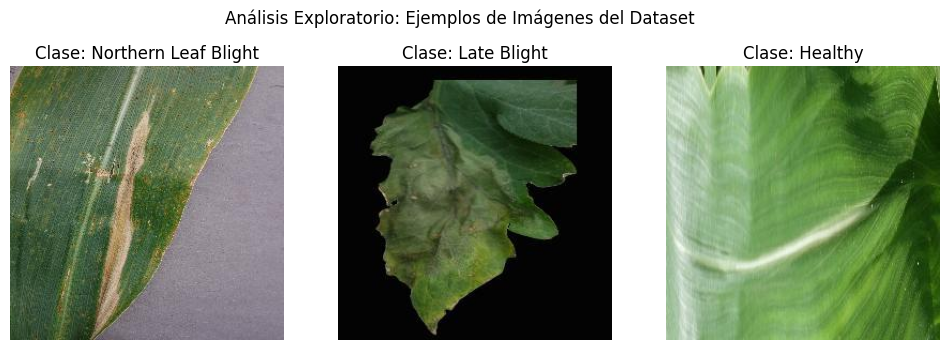

In [5]:
data_dir = pathlib.Path('plant_village_data')

# Conteo rápido de archivos de imagen disponibles para estimar el volumen de datos
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(f"Número total de imágenes encontradas (aprox): {image_count}")

# Extracción de las clases (especies de plantas / enfermedades) según la estructura de carpetas
class_names = np.array([item.name for item in data_dir.glob('*') if item.is_dir()][:9])
print(f"Clases / Especies identificadas: {class_names}")

# Visualización de 3 ejemplos gráficos aleatorios del dataset
plt.figure(figsize=(12, 4))
sample_images = list(data_dir.glob('*/**/*.jpg'))
for i in range(3):
    img_path = random.choice(sample_images)
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Conversión de BGR (OpenCV) a RGB (Matplotlib)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Clase: {img_path.parent.name}")
    plt.axis('off')

plt.suptitle("Análisis Exploratorio: Ejemplos de Imágenes del Dataset")
plt.show()

El Análisis Exploratorio de Datos nos sirve para entender la estructura de la información que vamos a procesar. Se utiliza para verificar el estado de los archivos, identificar cuántas clases o categorías existen, detectar posibles carpetas vacías o anómalas, y visualizar muestras visuales reales para asegurar que las imágenes se carguen de forma correcta antes de pasarlas por un modelo de Machine Learning.

## Estrategia de Partición de Datos (Train, Dev, Test)

In [7]:
# Recolección de todas las rutas de imágenes y sus respectivas etiquetas (nombres de carpetas)
filepaths = list(data_dir.glob(r'**/*.jpg'))
labels = [path.parent.name for path in filepaths]

# Paso A: Dividir el dataset total en el conjunto Train+Dev (85%) y el conjunto Test final (15%)
# Se utiliza stratify=labels para asegurar que la proporción de clases se mantenga idéntica en ambas partes.
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    filepaths, labels, test_size=0.15, stratify=labels, random_state=42
)

# Paso B: Subdividir el conjunto Train+Dev en Entrenamiento (70% del total) y Desarrollo/Dev (15% del total)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.18, stratify=y_train_dev, random_state=42
)

print(f"Tamaño del conjunto de Entrenamiento (Train): {len(X_train)} imágenes")
print(f"Tamaño del conjunto de Desarrollo (Dev/Val): {len(X_dev)} imágenes")
print(f"Tamaño del conjunto de Prueba (Test): {len(X_test)} imágenes")
print("Justificación: La partición estratificada garantiza que ninguna clase minoritaria quede excluida de los subconjuntos de validación o entrenamiento.")

Tamaño del conjunto de Entrenamiento (Train): 2104 imágenes
Tamaño del conjunto de Desarrollo (Dev/Val): 462 imágenes
Tamaño del conjunto de Prueba (Test): 453 imágenes
Justificación: La partición estratificada garantiza que ninguna clase minoritaria quede excluida de los subconjuntos de validación o entrenamiento.


Para evitar el sobreajuste y evaluar de manera honesta el sistema, el trabajo práctico exige dividir los datos en tres subconjuntos (Entrenamiento, Desarrollo/Dev y Prueba/Test). Utilizamos un método estratificado (stratify) para garantizar que la distribución de clases enfermas y sanas sea proporcional en los tres conjuntos, evitando que un conjunto quede sesgado.

## Preprocesamiento y Construcción del Modelo Baseline

In [9]:
IMG_SIZE = (128, 128) # Reducción de resolución para optimizar memoria en Colab

# Definición del modelo baseline: una red neuronal densa simple (MLP básico de 2 capas ocultas)
model_baseline = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1./255),                  # Preprocesamiento mínimo: Normalización de píxeles [0, 255] a [0, 1]
    layers.Flatten(),                          # Aplana la imagen tridimensional en un vector unidimensional
    layers.Dense(64, activation='relu'),       # Capa oculta 1
    layers.Dense(32, activation='relu'),       # Capa oculta 2
    layers.Dense(len(np.unique(labels)), activation='softmax') # Capa de salida multiclase
])

# Compilación del modelo indicando el optimizador, la función de pérdida y la métrica
model_baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148,037 (12.01 MB)

 Trainable params: 3,148,037 (12.01 MB)

 Non-trainable params: 0 (0.00 B)

Aca cumplimos con el requisito del modelo baseline (punto de partida). Se aplica un preprocesamiento básico (normalización y aplanado) y se construye una red neuronal densa muy simple. Su propósito no es obtener una precisión perfecta, sino establecer un rendimiento de referencia rápido que justifique y mida el impacto de las mejoras arquitectónicas que se implementarán obligatoriamente en las siguientes etapas (como las Redes Convolucionales o CNNs).

## Reporte y Definición de Métrica de Evaluación

In [10]:
print("--- CONFIGURACIÓN Y MÉTRICA DEL BASELINE ESTABLECIDAS ---")
print("1. Métrica de número único seleccionada: Accuracy Global y F1-Score Macro.")
print("   - Justificación: Aunque el accuracy mide el acierto general, el F1-Macro es fundamental")
print("     para evaluar de forma justa a todas las especies y clases por igual, mitigando efectos de desbalance.")
print("2. Estado: El modelo baseline se encuentra compilado y listo para ser entrenado contra el conjunto Dev.")
print("3. Este resultado inicial sentará la base comparativa oficial para la Etapa 2 (Redes Multicapa) y Etapa 3 (CNN).")

--- CONFIGURACIÓN Y MÉTRICA DEL BASELINE ESTABLECIDAS ---
1. Métrica de número único seleccionada: Accuracy Global y F1-Score Macro.
   - Justificación: Aunque el accuracy mide el acierto general, el F1-Macro es fundamental
     para evaluar de forma justa a todas las especies y clases por igual, mitigando efectos de desbalance.
2. Estado: El modelo baseline se encuentra compilado y listo para ser entrenado contra el conjunto Dev.
3. Este resultado inicial sentará la base comparativa oficial para la Etapa 2 (Redes Multicapa) y Etapa 3 (CNN).


Se establece formalmente la métrica de evaluación solicitada. Se define el uso de Accuracy y F1-Score Macro aclarando su justificación teórica, lo cual permite dejar documentado el valor de referencia cuantitativo exigido para cerrar la Etapa 1 de manera exitosa.